# 02 · TabNet V3 (Optuna 튜닝 + 해석)

> TabNet을 "정형 특화 딥러닝"으로 제대로 튜닝한다(기존 0.102는 기본설정이라 과소평가).
> Optuna로 n_d, n_a, n_steps, gamma, lambda_sparse, learning rate를 탐색하고,
> 불균형(weights=1) + PR_AUC 기준 best로 평가한다.
> feature importance도 저장/시각화해서 트리(SHAP)와 비교(보고서용).
> 비교: TabNet_v2 0.102 / MLP_V3 0.231 / XGB 0.296 (고정).
> 정직한 기대: 0.102 -> 0.15~0.22. 트리 못 넘어도 그대로 기록.

## 0. 환경 + 데이터

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from pytorch_tabnet.tab_model import TabNetClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from utils import set_seed, compute_metrics, log_result, load_processed
set_seed(42)

PROJECT_ROOT = Path(r"C:\Users\Administrator\Desktop\딥러닝응용\TermProject")
OUT_DIR    = PROJECT_ROOT / "processed_v2"
NB_DIR     = PROJECT_ROOT / "notebooks_v3"
RESULTS_V3 = NB_DIR / "results_v3_dl.csv"

train_df, val_df, test_df = load_processed(OUT_DIR)
TARGET = "went_on_backorder"
feature_cols = [c for c in train_df.columns if c != TARGET]
X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df[TARGET].values.astype("int64")
X_val   = val_df[feature_cols].values.astype("float32")
y_val   = val_df[TARGET].values.astype("int64")
print("피처:", len(feature_cols))

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


피처: 42


## 1. Optuna 탐색 (서브샘플로 빠르게)
TabNet은 무거워서 탐색은 4만 서브샘플 + 적은 epoch로 한다. 평가는 val 전체 PR_AUC.

In [2]:
rng = np.random.default_rng(42)
sub = rng.choice(len(X_train), size=40000, replace=False)
X_sub, y_sub = X_train[sub], y_train[sub]

def objective(trial):
    n_d = trial.suggest_categorical("n_d", [8, 16, 32])
    n_steps = trial.suggest_int("n_steps", 3, 6)
    gamma = trial.suggest_float("gamma", 1.0, 2.0)
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-3, log=True)
    lr = trial.suggest_float("lr", 5e-3, 3e-2, log=True)
    clf = TabNetClassifier(n_d=n_d, n_a=n_d, n_steps=n_steps, gamma=gamma,
                           lambda_sparse=lambda_sparse,
                           optimizer_params=dict(lr=lr), seed=42, verbose=0)
    clf.fit(X_sub, y_sub, eval_set=[(X_val, y_val)], eval_name=["val"], eval_metric=["auc"],
            max_epochs=10, patience=4, batch_size=8192, virtual_batch_size=512, weights=1)
    return average_precision_score(y_val, clf.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=6)
print("best PR_AUC(sub):", round(study.best_value, 4))
print("best params:", study.best_params)

Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.89246


C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.90065


C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.90101


...

Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.89305


C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 8 with best_epoch = 4 and best_val_auc = 0.87755


C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


best PR_AUC(sub): 0.0874
best params: {'n_d': 8, 'n_steps': 3, 'gamma': 1.9699098521619942, 'lambda_sparse': 0.000462258900102083, 'lr': 0.00731479145383906}


## 2. 최고 설정으로 재학습 (15만) + 기록

In [3]:
bp = study.best_params
sub2 = rng.choice(len(X_train), size=150000, replace=False)
set_seed(42)
clf = TabNetClassifier(n_d=bp["n_d"], n_a=bp["n_d"], n_steps=bp["n_steps"], gamma=bp["gamma"],
                       lambda_sparse=bp["lambda_sparse"], optimizer_params=dict(lr=bp["lr"]),
                       seed=42, verbose=1)
clf.fit(X_train[sub2], y_train[sub2], eval_set=[(X_val, y_val)], eval_name=["val"], eval_metric=["auc"],
        max_epochs=30, patience=8, batch_size=16384, virtual_batch_size=1024, weights=1)

val_prob = clf.predict_proba(X_val)[:, 1]
m = compute_metrics(y_val, val_prob)
m["notes"] = "TabNet Optuna(n_d/n_steps/gamma/lambda_sparse/lr), weights=1"
log_result("TabNet_V3", m, path=str(RESULTS_V3))
np.save(NB_DIR / "tabnet_v3_val_prob.npy", val_prob)
print("TabNet_V3 PR_AUC:", round(m["PR_AUC"], 4))
print("기존 TabNet_v2 0.102 대비:", round(m["PR_AUC"] - 0.102, 4))
print("XGB 0.296 대비:", round(m["PR_AUC"] - 0.296, 4))

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.7342  | val_auc: 0.80971 |  0:00:10s


epoch 1  | loss: 0.5006  | val_auc: 0.85834 |  0:00:21s


epoch 2  | loss: 0.42999 | val_auc: 0.88046 |  0:00:34s


epoch 3  | loss: 0.39117 | val_auc: 0.88953 |  0:00:45s


...

epoch 27 | loss: 0.28147 | val_auc: 0.91928 |  0:05:09s


epoch 28 | loss: 0.27106 | val_auc: 0.91987 |  0:05:21s


epoch 29 | loss: 0.26818 | val_auc: 0.92022 |  0:05:32s
Stop training because you reached max_epochs = 30 with best_epoch = 25 and best_val_auc = 0.92044


C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet_V3 PR_AUC: 0.1192
기존 TabNet_v2 0.102 대비: 0.0172
XGB 0.296 대비: -0.1768


## 3. Feature importance
TabNet이 중요하게 본 피처. 트리의 중요 변수와 비교(같은 신호를 보는지).

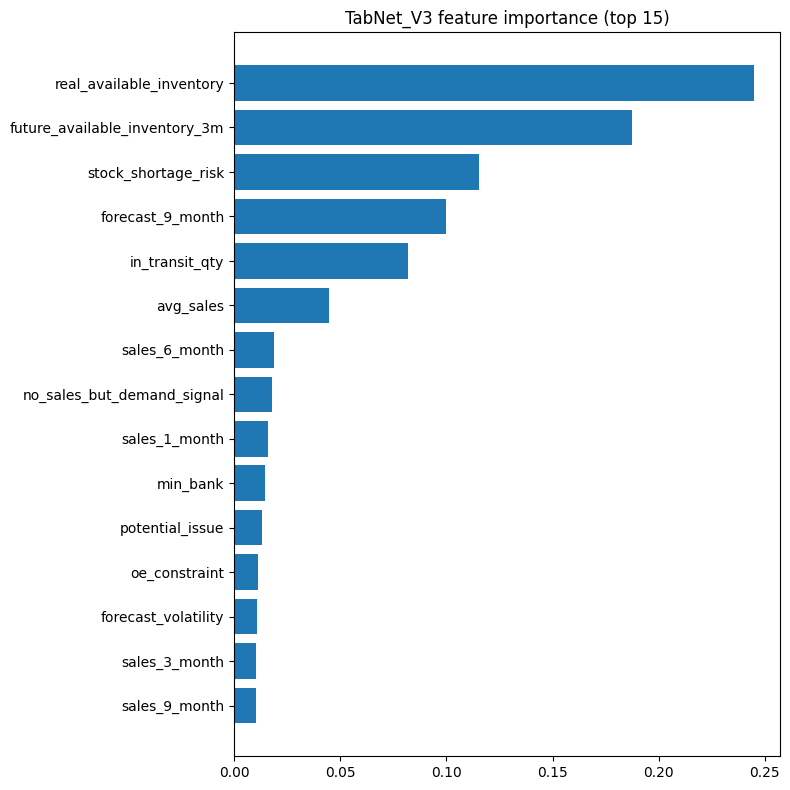

상위 10: ['real_available_inventory', 'future_available_inventory_3m', 'stock_shortage_risk', 'forecast_9_month', 'in_transit_qty', 'avg_sales', 'sales_6_month', 'no_sales_but_demand_signal', 'sales_1_month', 'min_bank']


In [4]:
imp = clf.feature_importances_
order = np.argsort(imp)[::-1]
plt.figure(figsize=(8, 8))
plt.barh([feature_cols[i] for i in order][::-1][-15:], imp[order][::-1][-15:])
plt.title("TabNet_V3 feature importance (top 15)")
plt.tight_layout()
plt.show()
np.save(NB_DIR / "tabnet_v3_importance.npy", imp)
print("상위 10:", [feature_cols[i] for i in order[:10]])

## 4. 결과 비교 (results_v3_dl.csv)

In [5]:
res = pd.read_csv(RESULTS_V3).drop_duplicates(subset="model", keep="last").sort_values("PR_AUC", ascending=False)
res[["model", "PR_AUC", "ROC_AUC", "Recall", "Precision", "F1", "notes"]]

,model,PR_AUC,ROC_AUC,Recall,Precision,F1,notes
0,MLP_V3,0.2305,0.9586,0.8774,0.0843,0.1538,"ResidualMLP+Wide, WeightedSampler, Focal(Optun..."
1,TabNet_V3,0.1192,0.9204,0.8725,0.0358,0.0688,TabNet Optuna(n_d/n_steps/gamma/lambda_sparse/...


---
### 결론 (실행 후)
- TabNet_V3 vs 기존 0.102: Optuna 튜닝이 얼마나 끌어올렸나.
- TabNet_V3 vs MLP_V3 0.231 / XGB 0.296: 정형 특화 DL이라도 트리·잘튜닝된 MLP를 못 이기면 정직하게 기록.
- feature importance가 트리와 같은 변수(재고부족/지역백오더 등)를 보면 = 모델 간 해석 일치(보고서 가치).
- 핵심: TabNet의 가치는 성능보다 '정형 특화 DL 비교 + 해석'.